In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_pickle("LabDelSole.pickle")

colori = sns.color_palette("pastel")

In [96]:
#IMPORTANTE, QUI CREIAMO UN DF PER LA VISIONE TEMPORALE

ordine_stagioni = [
    "aut 23", "inv 23", 
    "prim 24", "est 24", "aut 24", "inv 24", 
    "prim 25", "est 25", "aut 25", "inv 25", 
    "prim 26", "est 26"
]

df_stagionale = pd.DataFrame({
    "guadagno totale": df["venduti"].T.dot(df[("info", "prezzo")]),
    "mercatini": df["mercatino"].T.dot(df[("info", "prezzo")]),
    "passaparola": df["passaparola"].T.dot(df[("info", "prezzo")]),
    "ore": df["venduti"].T.dot(df[("info", "ore impiegate")])
})

df_stagionale = df_stagionale.reindex(ordine_stagioni)
df_stagionale = df_stagionale.reset_index().rename(columns={"index": "stagione"})
df_stagionale["prezzo_ora"] = df_stagionale["guadagno totale"] / df_stagionale["ore"]

df_stagionale

,stagione,guadagno totale,mercatini,passaparola,ore,prezzo_ora
0,aut 23,140.0,NaN,140.0,18.0,7.777778
1,inv 23,190.0,NaN,190.0,26.0,7.307692
2,prim 24,140.0,NaN,140.0,16.0,8.750000
3,est 24,470.0,250.0,220.0,46.0,10.217391
4,aut 24,225.0,NaN,225.0,26.0,8.653846
5,inv 24,360.0,115.0,245.0,33.0,10.909091
6,prim 25,125.0,NaN,125.0,11.0,11.363636
7,est 25,150.0,NaN,150.0,16.0,9.375000
8,aut 25,230.0,100.0,130.0,24.0,9.583333
9,inv 25,185.0,NaN,185.0,18.0,10.277778


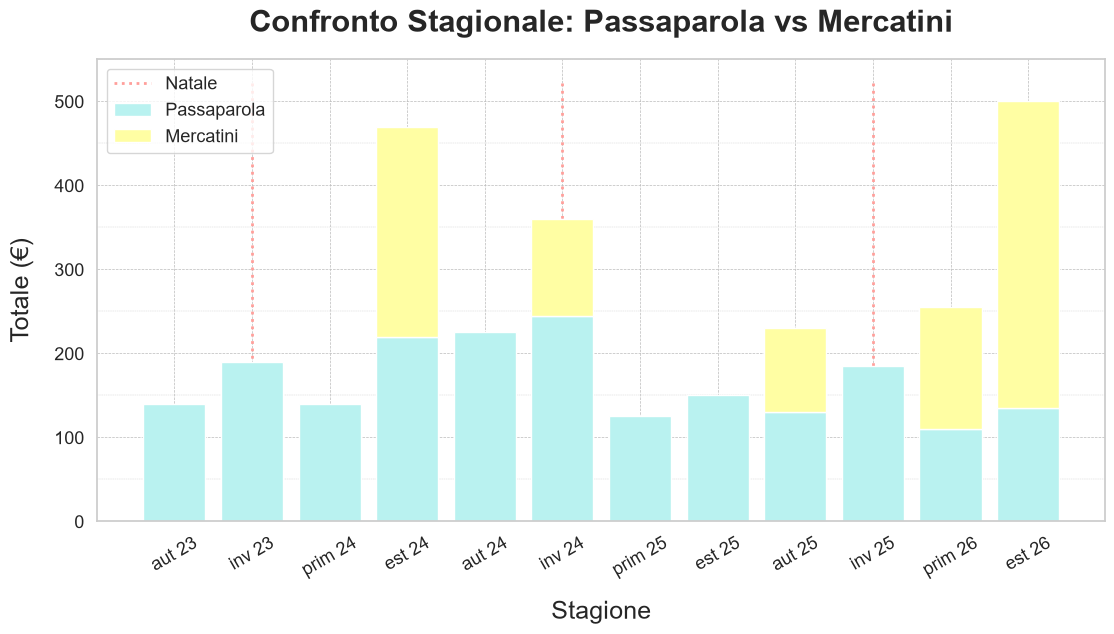

In [122]:
#GRAFICO 1
#questo ci piace e lo mettiamo

fig, ax = plt.subplots(figsize = (13, 6))

plt.bar(
    df_stagionale["stagione"], 
    df_stagionale["passaparola"], 
    label="Passaparola", 
    color=colori[9], 
    zorder=2
)

plt.bar(
    df_stagionale["stagione"], 
    df_stagionale["mercatini"], 
    bottom=df_stagionale["passaparola"], 
    label="Mercatini", 
    color=colori[8], 
    zorder=2
)

for i in range (3):
    ax.axvline(
        i*4+1, 
        color=colori[3], 
        linewidth=2, 
        linestyle=":", 
        ymin=0.05, 
        ymax=0.95, 
        label="Natale" if i == 0 else None,
        zorder=1
    )

ax.grid(True, color = "#BBBBBB", linewidth = 0.5, linestyle="--")
ax.grid(True, axis = 'y', which = 'minor',linewidth = 0.3, linestyle="--")

ax.set_xlabel("Stagione", fontsize = 18, fontweight = "normal", labelpad = 15)
ax.set_ylabel("Totale (€)", fontsize = 18, fontweight = "normal", labelpad = 15)
ax.set_title("Confronto Stagionale: Passaparola vs Mercatini", pad = 20, fontsize = 22, fontweight = "bold")

ax.yaxis.set_major_locator(plt.MultipleLocator(100))
ax.yaxis.set_minor_locator(plt.MultipleLocator(50))
ax.set_ylim(0, 550)

plt.xticks(rotation=30)
plt.legend(loc="upper left")

plt.savefig("Immagini/Passaparola-Mercatini.svg", bbox_inches = "tight", pad_inches = 0.3, transparent = False)
plt.savefig("Immagini/Passaparola-Mercatini.png", bbox_inches = "tight", pad_inches = 0.3, transparent = False)

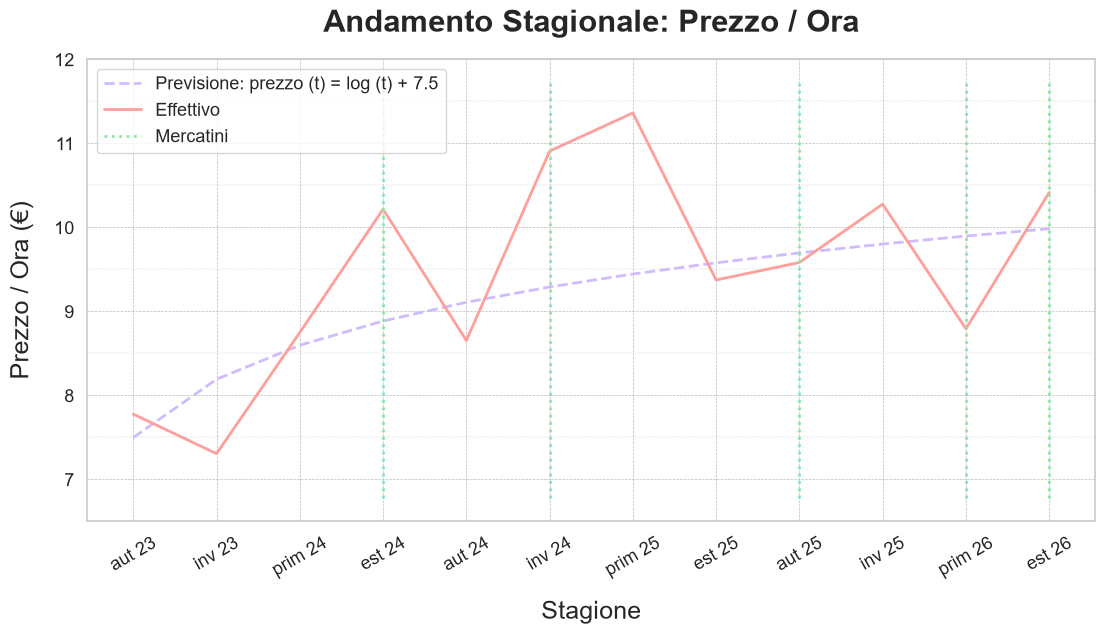

In [128]:
sns.set_theme(style="whitegrid", font_scale = 1.2)

fig, ax = plt.subplots(figsize = (13, 6))

n = len(df_stagionale["stagione"])
t = np.arange(1, n + 1)
prezzo_teorico = np.log(t) + 7.5

ax.plot(
    np.arange(n),
    prezzo_teorico,
    linestyle="--",
    linewidth=2,
    color=colori[4],
    label="Previsione: prezzo (t) = log (t) + 7.5"
)

sns.lineplot(
    data=df_stagionale, 
    x="stagione", 
    y="prezzo_ora", 
    linewidth=2, 
    color=colori[3],
    label="Effettivo"
)

ax.set_facecolor("#FFFFFF")

ax.grid(True, color = "#BBBBBB", linewidth = 0.5, linestyle="--")
ax.grid(True, axis = 'y', which = 'minor',linewidth = 0.3, linestyle="--")

mercatini_x = [3, 5, 8, 10, 11]

for i, x in enumerate(mercatini_x):
    ax.axvline(
        x,
        color=colori[2],
        linewidth=2,
        linestyle=":",
        ymin=0.05,
        ymax=0.95,
        label="Mercatini" if i == 0 else None
    )

ax.set_title("Andamento Stagionale: Prezzo / Ora", pad = 20, fontsize = 22, fontweight = "bold")
ax.set_xlabel("Stagione", fontsize = 18, fontweight = "normal", labelpad = 15)
ax.set_ylabel("Prezzo / Ora (€)", fontsize = 18, fontweight = "normal", labelpad = 15)

ax.yaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax.set_ylim(6.5, 12)
ax.legend(loc="upper left")
plt.xticks(rotation=30)

plt.savefig("Immagini/Prezzo-Ora.svg", bbox_inches = "tight", pad_inches = 0.3, transparent = False)
plt.savefig("Immagini/Prezzo-Ora.png", bbox_inches = "tight", pad_inches = 0.3, transparent = False)